In [1]:
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from deep_isochron.model.invertible import (
    MonotonicRationalQuadraticSpline,
    MonotonicRQCoupling,
)

In [2]:
xs = jnp.linspace(-1, 1, 10)
ys = jnp.linspace(-1, 1, 10)
ds = jax.random.uniform(jax.random.key(0), (10,), minval=0.2, maxval=5.0)

spline = MonotonicRationalQuadraticSpline(xs, ys, ds)

In [3]:
x_test = jnp.linspace(-1.1, 1.1, 100)
y_test = jax.jit(jax.vmap(spline))(x_test)
x_inv_test = jax.vmap(spline.inverse)(y_test)

In [4]:
jnp.max(jnp.abs(x_test - x_inv_test))

Array(1.1920929e-07, dtype=float32)

In [5]:
y_test

Array([-1.4748802 , -1.3693511 , -1.2638218 , -1.1582938 , -1.0527647 ,
       -0.96282095, -0.92933714, -0.9129875 , -0.9024259 , -0.89414114,
       -0.88645816, -0.8780902 , -0.8673308 , -0.85056937, -0.8161056 ,
       -0.7350524 , -0.68783367, -0.6618399 , -0.64486086, -0.6323362 ,
       -0.62205446, -0.6126153 , -0.6027315 , -0.5905051 , -0.5715039 ,
       -0.53793186, -0.51212615, -0.49314246, -0.47746366, -0.46316004,
       -0.44887418, -0.43333247, -0.41494283, -0.391183  , -0.35720122,
       -0.31057948, -0.2813595 , -0.26239938, -0.24799171, -0.23553818,
       -0.22344649, -0.21032917, -0.19442903, -0.1727007 , -0.1382832 ,
       -0.08221852, -0.04035076, -0.01110031,  0.01093236,  0.02860485,
        0.04364379,  0.05725926,  0.07048795,  0.0844871 ,  0.10098706,
        0.12181582,  0.1416274 ,  0.16015059,  0.17817992,  0.19638214,
        0.21538967,  0.2358769 ,  0.2586422 ,  0.28471604,  0.3155281 ,
        0.34929204,  0.3708764 ,  0.38600618,  0.39851293,  0.41

In [6]:
jnp.max(x_inv_test - x_test)

Array(1.1920929e-07, dtype=float32)

In [7]:
ds[0]

Array(4.7488017, dtype=float32)

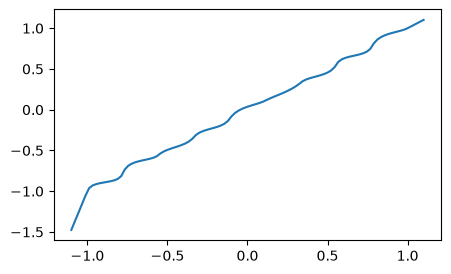

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x_test, y_test)

In [9]:
inn = MonotonicRQCoupling(dim=2, key=jax.random.key(0), xy_range=(-5, 5))

In [12]:
x_test = jax.random.uniform(jax.random.key(10), (100, 2), minval=-3, maxval=3)
y_test = eqx.filter_vmap(inn)(x_test)
x_recon = eqx.filter_vmap(inn.inverse)(y_test)

In [13]:
x_test.shape

(100, 2)

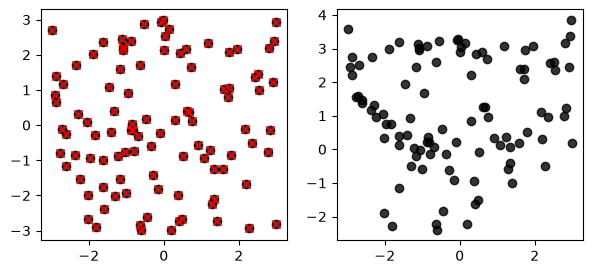

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].scatter(*x_test.T, marker="o", color="black", alpha=0.8)
axes[0].scatter(*x_recon.T, marker="x", color="red", alpha=0.8)
axes[1].scatter(*y_test.T, color="black", alpha=0.8)